In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier 
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [4]:
df_orginal=sns.load_dataset('titanic')
df_orginal.shape

(891, 15)

In [5]:
df=df_orginal.copy(deep=True)

In [7]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [8]:
df=df[['age','fare','survived']]

In [9]:
df

,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0
...,...,...,...
886,27.0,13.0000,0
887,19.0,30.0000,1
888,NaN,23.4500,0
889,26.0,30.0000,1


In [10]:
df.isnull().sum()

age         177
fare          0
survived      0
dtype: int64

In [11]:
# so age has 177 null values
df['age'].fillna(df['age'].mean(),inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_32184\402931334.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(),inplace=True)


In [12]:
df.isnull().sum()

age         0
fare        0
survived    0
dtype: int64

In [14]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]
X
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

[]

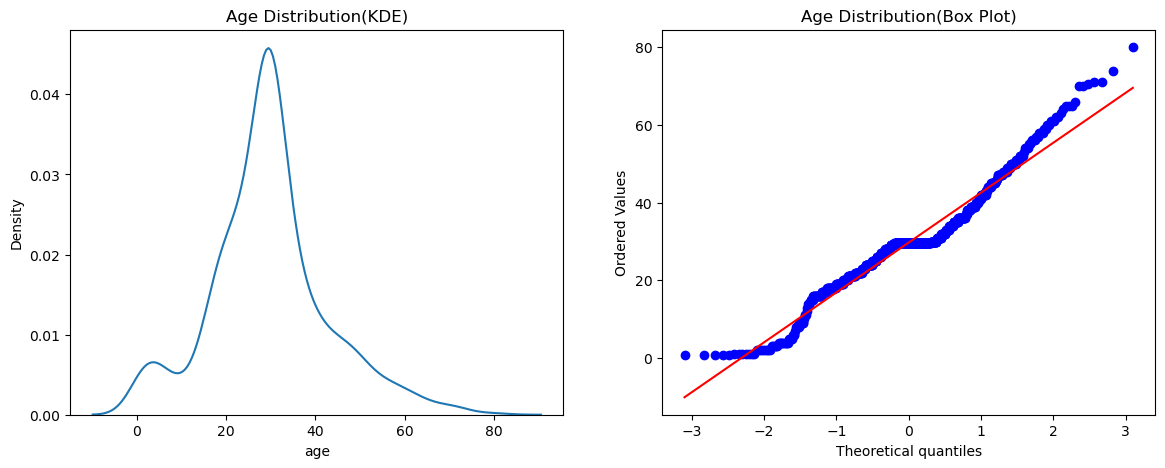

In [20]:
fig,axes = plt.subplots(1,2,figsize=(14,5))
sns.kdeplot(X_train['age'],ax=axes[0])
stats.probplot(X_train['age'],dist='norm',plot=axes[1])
axes[0].set_title('Age Distribution(KDE)')
axes[1].set_title('Age Distribution(Box Plot)')
plt.plot()

[]

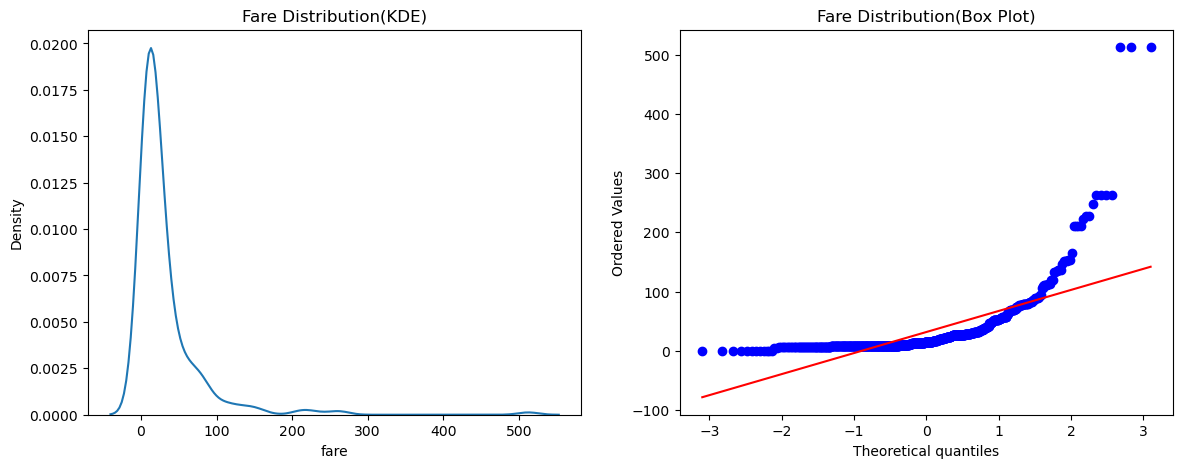

In [21]:
fig,axes = plt.subplots(1,2,figsize=(14,5))
sns.kdeplot(X_train['fare'],ax=axes[0])
stats.probplot(X_train['fare'],dist='norm',plot=axes[1])
axes[0].set_title('Fare Distribution(KDE)')
axes[1].set_title('Fare Distribution(Box Plot)')
plt.plot()

In [ ]:
# we can clearly see the data of fare is right skewed
df['fare'].skew()# skewness also proves that the data is right skewed

np.float64(4.787316519674893)

In [23]:
model1=LogisticRegression()
model2=DecisionTreeClassifier()

In [24]:
model1.fit(X_train,y_train)
model2.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
y_pred1=model1.predict(X_test)
y_pred2=model2.predict(X_test)

In [26]:
print('Accuracy of Logistic Regression:',accuracy_score(y_test,y_pred1))
print('Accuracy of Decision Tree:',accuracy_score(y_test,y_pred2))

Accuracy of Logistic Regression: 0.6983240223463687
Accuracy of Decision Tree: 0.6759776536312849


In [27]:
transformer=FunctionTransformer(np.log1p)

In [28]:
X_train_transformed=transformer.fit_transform(X_train)
X_test_transformed=transformer.transform(X_test)

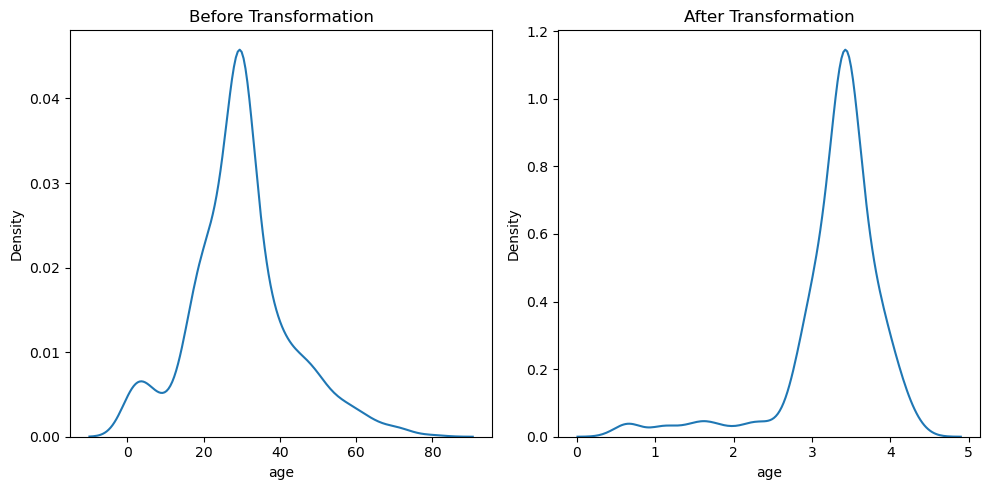

In [36]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

sns.kdeplot(X_train['age'], ax=ax[0])
ax[0].set_title("Before Transformation")

sns.kdeplot(X_train_transformed['age'], ax=ax[1])
ax[1].set_title("After Transformation")

plt.tight_layout()
plt.show()

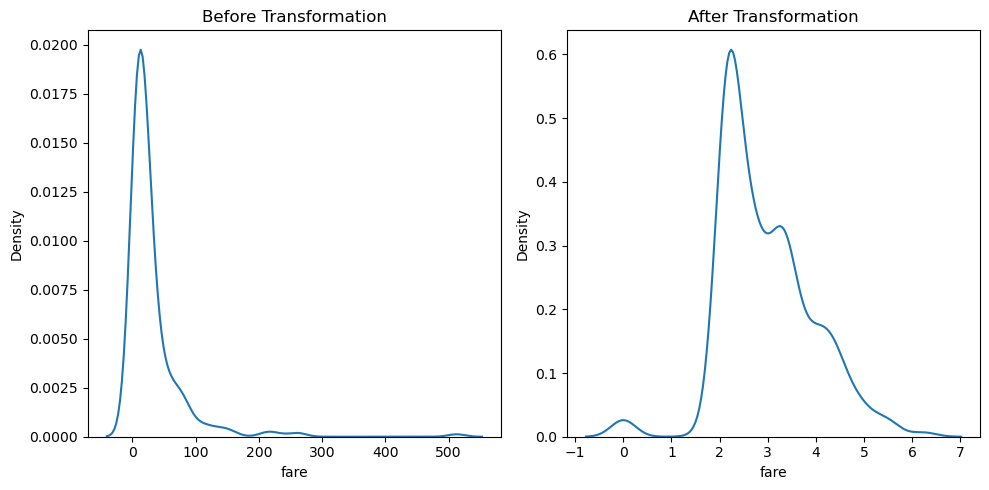

In [37]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

sns.kdeplot(X_train['fare'], ax=ax[0])
ax[0].set_title("Before Transformation")

sns.kdeplot(X_train_transformed['fare'], ax=ax[1])
ax[1].set_title("After Transformation")

plt.tight_layout()
plt.show()

In [38]:
model1=LogisticRegression()
model2=DecisionTreeClassifier()


In [39]:
model1.fit(X_train_transformed,y_train)
model2.fit(X_train_transformed,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [40]:
y_pred1=model1.predict(X_test_transformed)
y_pred2=model2.predict(X_test_transformed)

In [41]:
print('Accuracy of Logistic Regression:',accuracy_score(y_test,y_pred1))
print('Accuracy of Decision Tree:',accuracy_score(y_test,y_pred2))

Accuracy of Logistic Regression: 0.7039106145251397
Accuracy of Decision Tree: 0.6703910614525139


In [ ]:
# so we can say linear model like logistic regression accuracy increased as we perform log transformation but decission tree accuracy does not effect much as it does not depends on normally distributed data

In [42]:
transformed_x=transformer.fit_transform(X)

model1=LogisticRegression()
model2=DecisionTreeClassifier()
print("LR",np.mean(cross_val_score(model1,transformed_x,y,cv=10)))
print("DT",np.mean(cross_val_score(model2,transformed_x,y,cv=10)))

LR 0.678027465667915
DT 0.6633208489388264


In [ ]:
# now also there is slightly better result after cross validation of 10 fold

In [43]:
transformer2=ColumnTransformer(
    [
        ('log',FunctionTransformer(np.log1p),['fare'])
    ],
    remainder='passthrough'
)

In [44]:
X_train_transformed=transformer2.fit_transform(X_train)
X_test_transformed=transformer2.transform(X_test)

In [45]:
model1=LogisticRegression()
model2=DecisionTreeClassifier()

In [46]:
model1.fit(X_train_transformed,y_train)
model2.fit(X_train_transformed,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [47]:
y_pred1=model1.predict(X_test_transformed)
y_pred2=model2.predict(X_test_transformed)

In [48]:
print('Accuracy of Logistic Regression:',accuracy_score(y_test,y_pred1))
print('Accuracy of Decision Tree:',accuracy_score(y_test,y_pred2))

Accuracy of Logistic Regression: 0.6815642458100558
Accuracy of Decision Tree: 0.6703910614525139


In [ ]:
# co we dont need to do transformation on age as we get almost same accuray by applying log transformation on fare

In [59]:
df.head()

,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [60]:
# i created a function that takes the transformation as an argument divides the data in X and y apply transformation on X and then train the model print the accuracy and plot the distribution before and after transformation
def apply_transform(transform):
    X=df.iloc[:,0:2]
    y=df.iloc[:,-1]
    transformation=ColumnTransformer(
        [
            ('log',FunctionTransformer(transform),['fare'])
        ],
        remainder='passthrough'
    )
    X_transformed=transformation.fit_transform(X)
    model=LogisticRegression()
    model.fit(X_transformed,y)
    print("Accuracy",np.mean(cross_val_score(model,X_transformed,y,cv=10,scoring='accuracy')))
    fix,ax=plt.subplots(1,2,figsize=(10,5))
    sns.kdeplot(X['fare'],ax=ax[0])      
    sns.kdeplot(X_transformed[:,0],ax=ax[1])
    plt.show()
    

Accuracy 0.6589013732833957


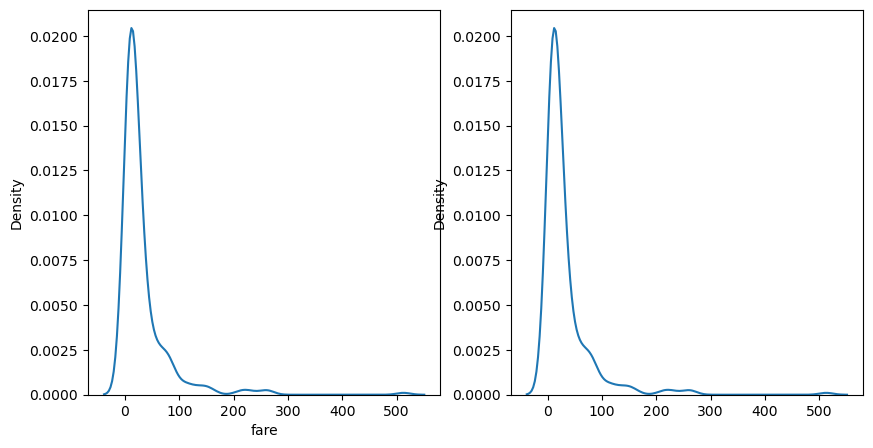

In [61]:
apply_transform(lambda x:x)

Accuracy 0.6262796504369538


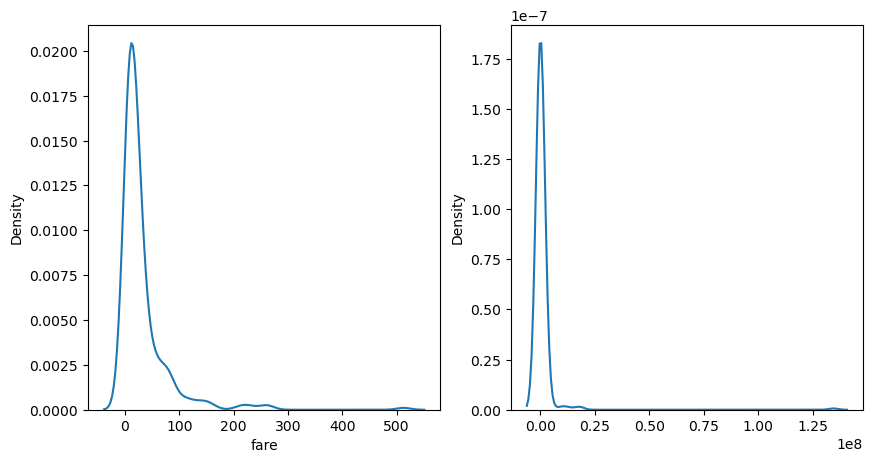

In [62]:
apply_transform(lambda x:x**3)

Accuracy 0.6431335830212235


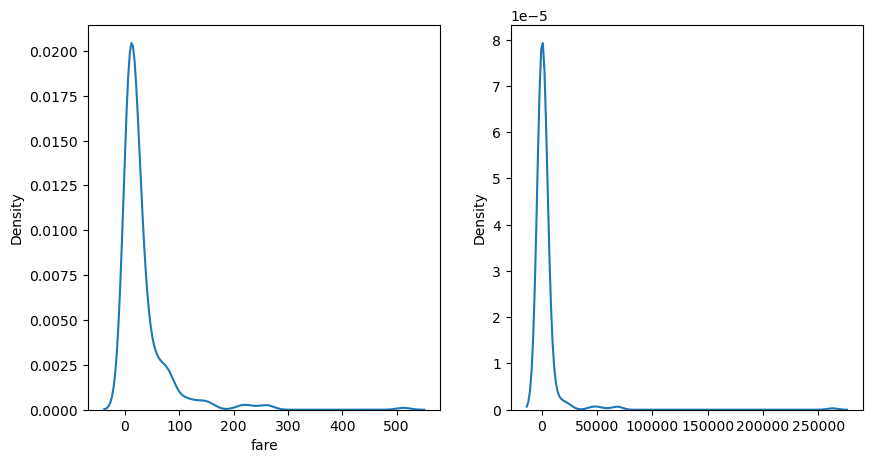

In [63]:
apply_transform(lambda x:x**2)

Accuracy 0.6566541822721598


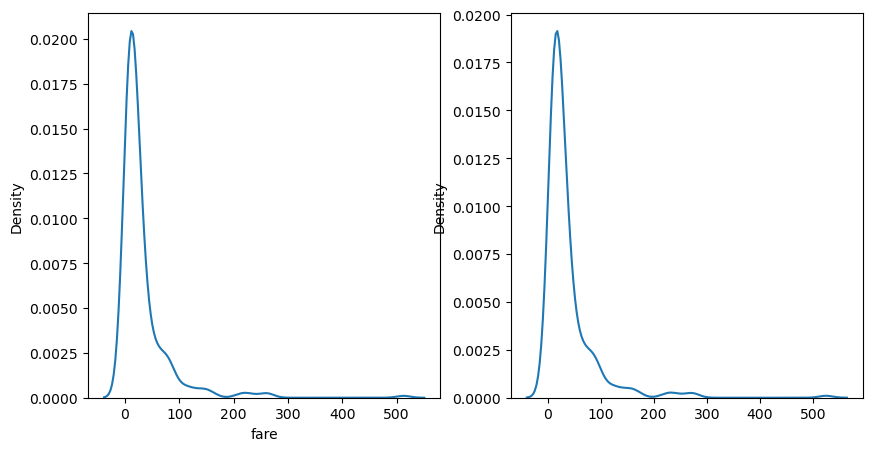

In [65]:
apply_transform(lambda x:x+np.log1p(x**2))

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer


In [8]:
df_orginal=pd.read_csv('concrete_data.csv')
df_orginal.shape

(1030, 9)

In [9]:
df_orginal.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [10]:
df_orginal.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [11]:
df_orginal.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [12]:
df_orginal.describe()# there are min value as 0 but no negative data

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [13]:
df=df_orginal.copy(deep=True)
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [15]:
X=df.iloc[:,0:8]
y=df.iloc[:,-1]
X
y

0       79.99
1       61.89
2       40.27
3       41.05
4       44.30
        ...  
1025    44.28
1026    31.18
1027    23.70
1028    32.77
1029    32.40
Name: Strength, Length: 1030, dtype: float64

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [17]:
lr=LinearRegression()

In [18]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
y_predict=lr.predict(X_test)

In [21]:
print("Accuracy of Linear Regression:",r2_score(y_test,y_predict))

Accuracy of Linear Regression: 0.6369606518338298


In [25]:
lr=LinearRegression()
print("LinearRegression Crossvalidation:",np.mean(cross_val_score(lr,X,y,scoring='r2').mean()))

LinearRegression Crossvalidation: 0.46099404916628667


In [26]:
import scipy.stats as stats

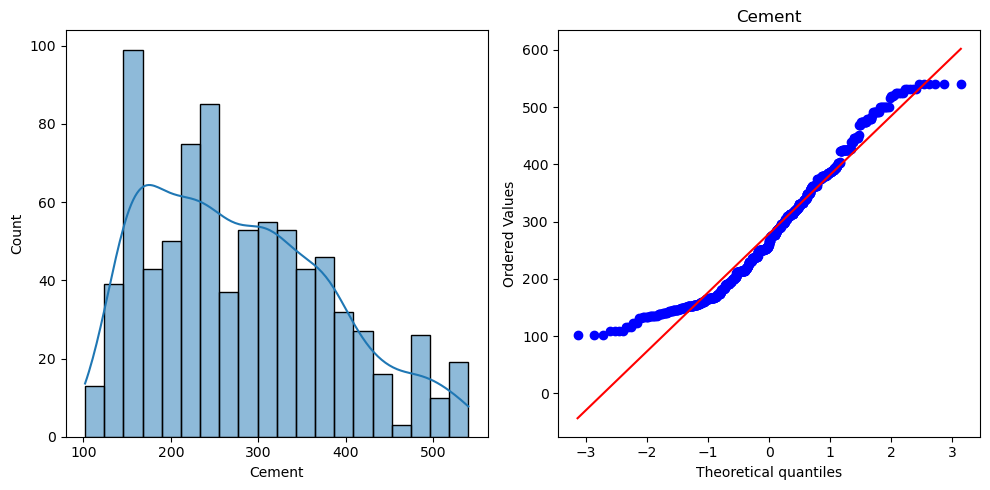

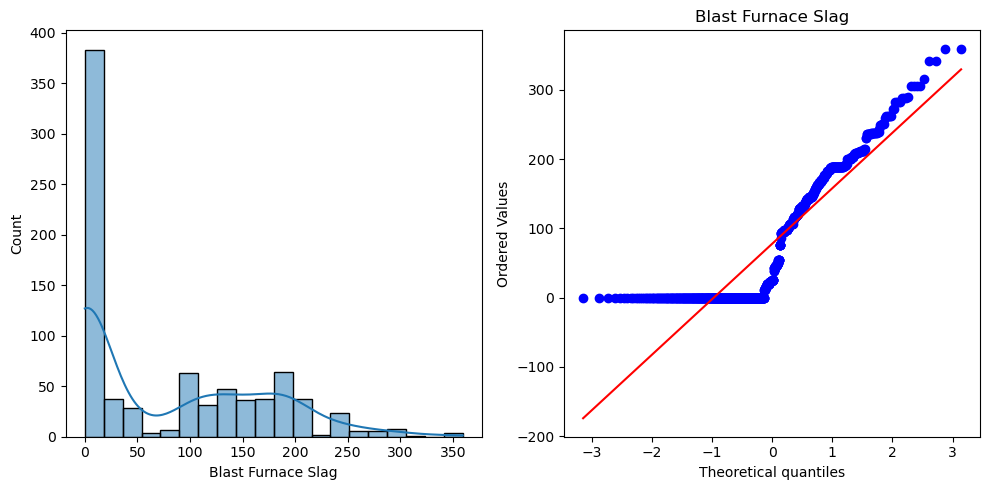

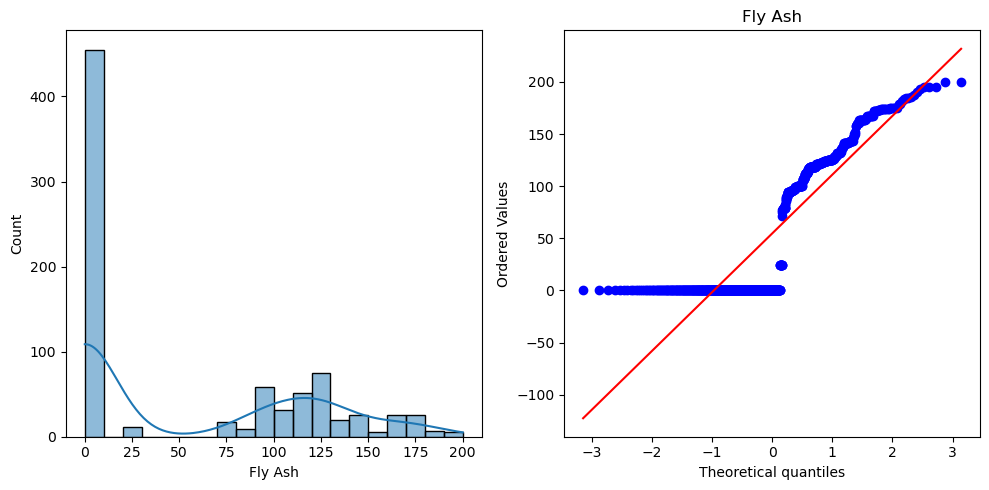

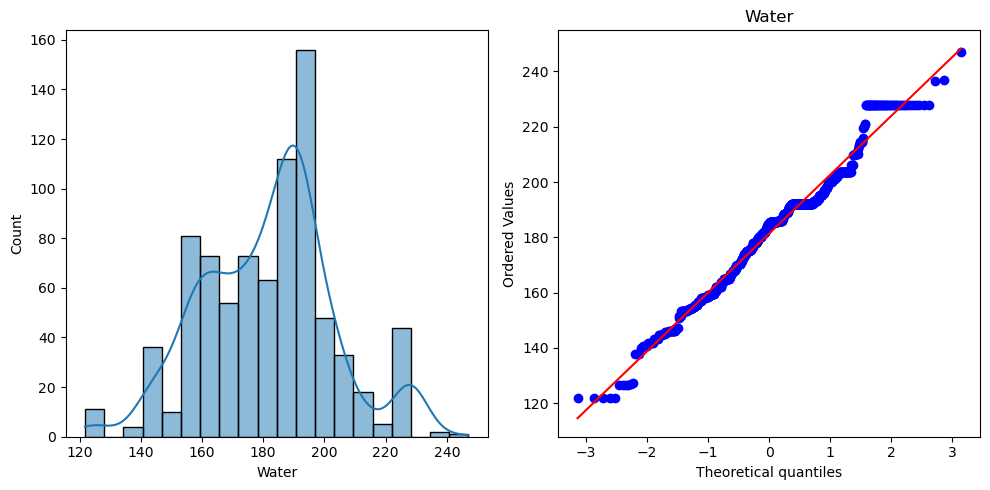

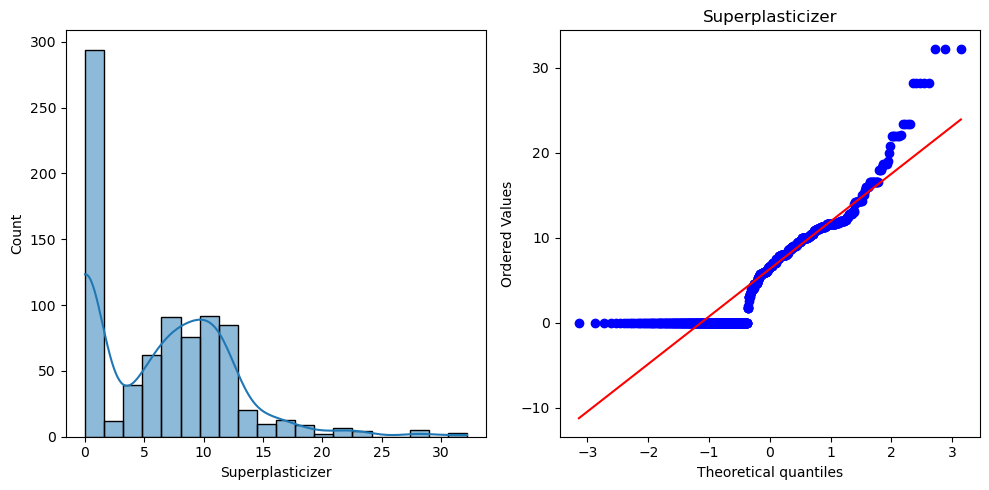

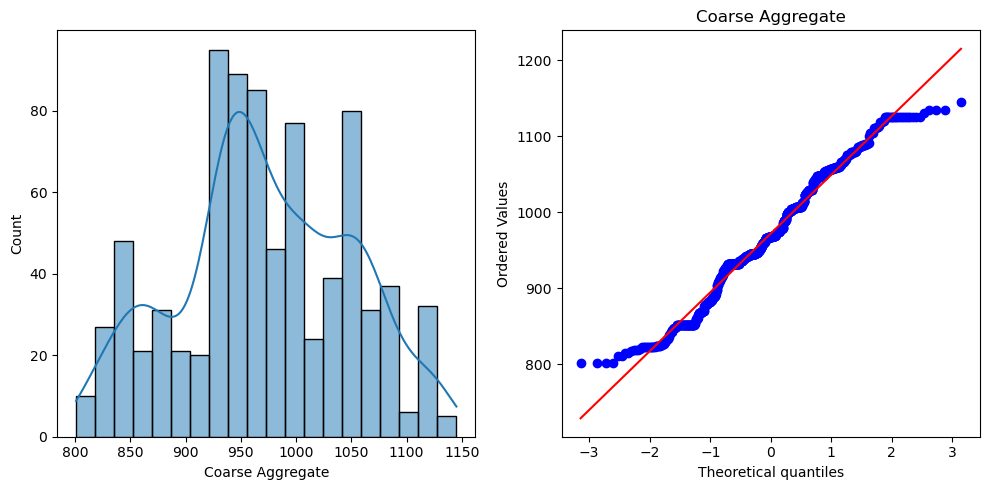

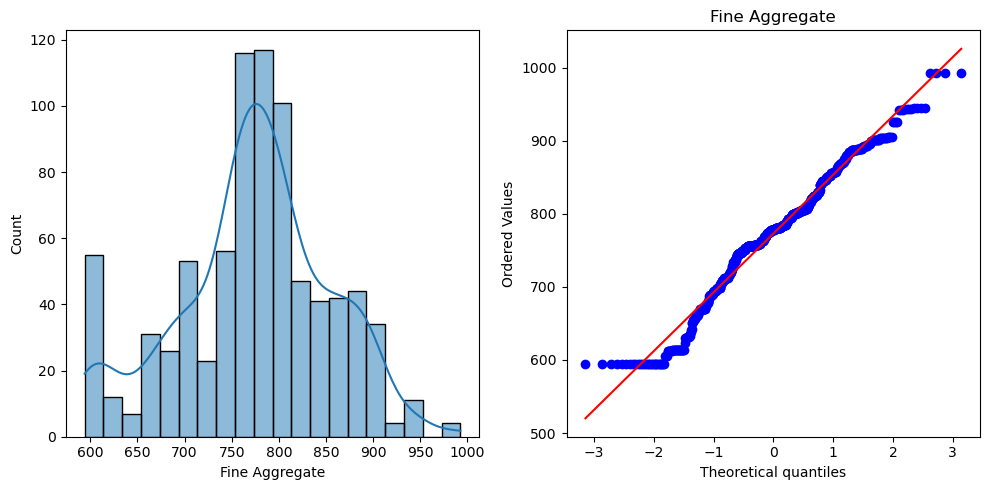

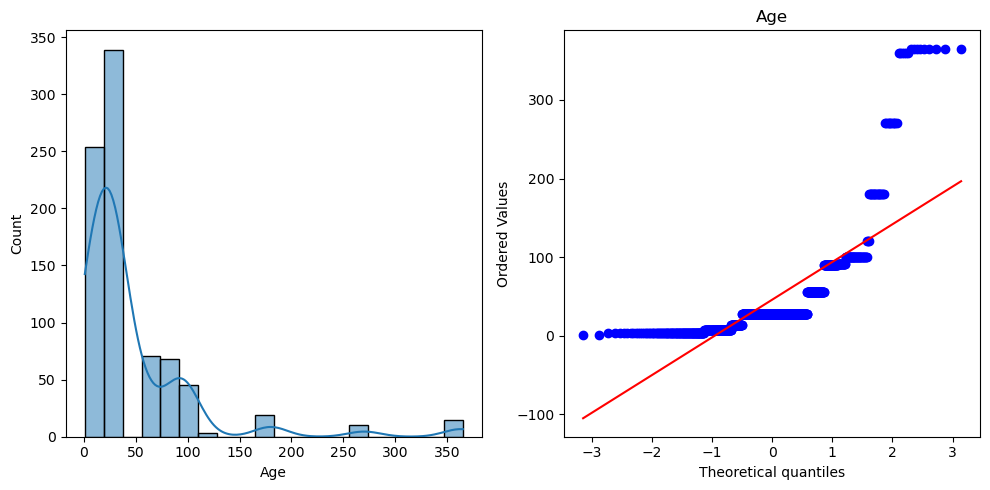

In [32]:
for col in X_train.columns:
    fig,ax=plt.subplots(1,2,figsize=(10,5))
    sns.histplot(X_train[col],ax=ax[0],kde=True,bins=20)
    plt.title(col)

    stats.probplot(X_train[col],dist='norm',plot=ax[1])
    plt.title(col)
    plt.tight_layout()
    plt.show()



In [43]:
pt=PowerTransformer(method='box-cox')


In [44]:
X_train_transformed=pt.fit_transform(X_train+0.000001)# to handel zero values
X_test_transformed=pt.transform(X_test+0.000001)

In [45]:
pd.DataFrame(
    {
    'Column':X_train.columns,
    'Lambdas':pt.lambdas_
    }
)

,Column,Lambdas
0,Cement,0.153049
1,Blast Furnace Slag,0.031295
2,Fly Ash,-0.034123
3,Water,0.888072
4,Superplasticizer,0.108879
5,Coarse Aggregate,1.115681
6,Fine Aggregate,1.789591
7,Age,0.063010


In [46]:
lr=LinearRegression()

In [47]:
lr.fit(X_train_transformed,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
y_predict=lr.predict(X_test_transformed)
print("Accuracy of Linear Regression:",r2_score(y_test,y_predict))

Accuracy of Linear Regression: 0.8134350083716209


In [49]:
# Using cross val score

pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X+0.0000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))

np.float64(0.6658537941434355)

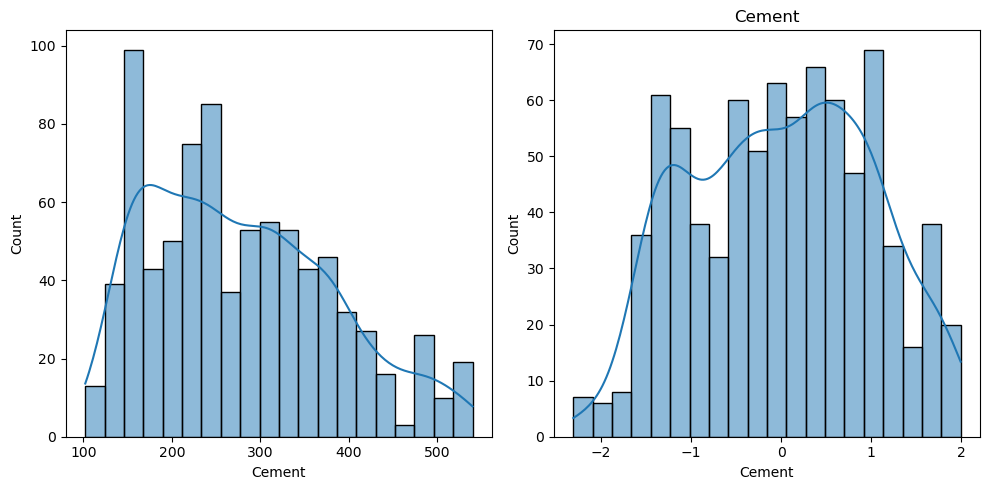

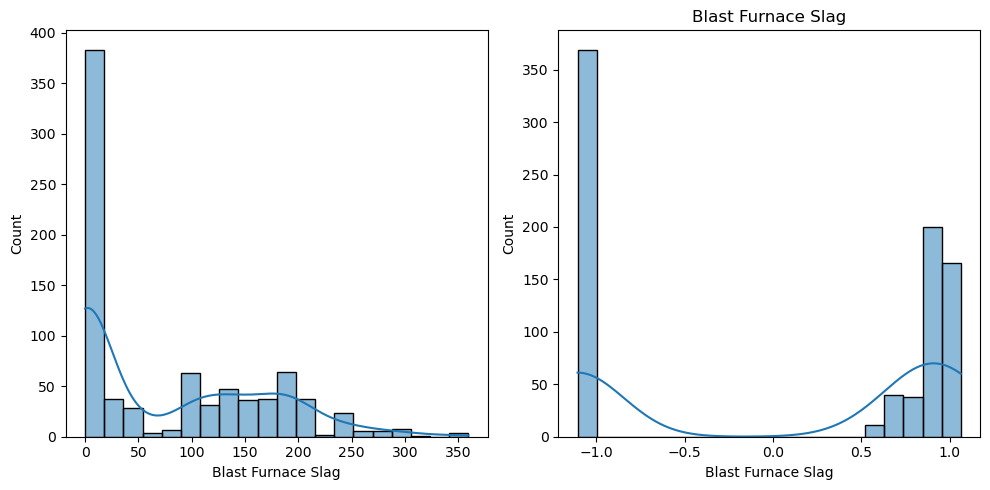

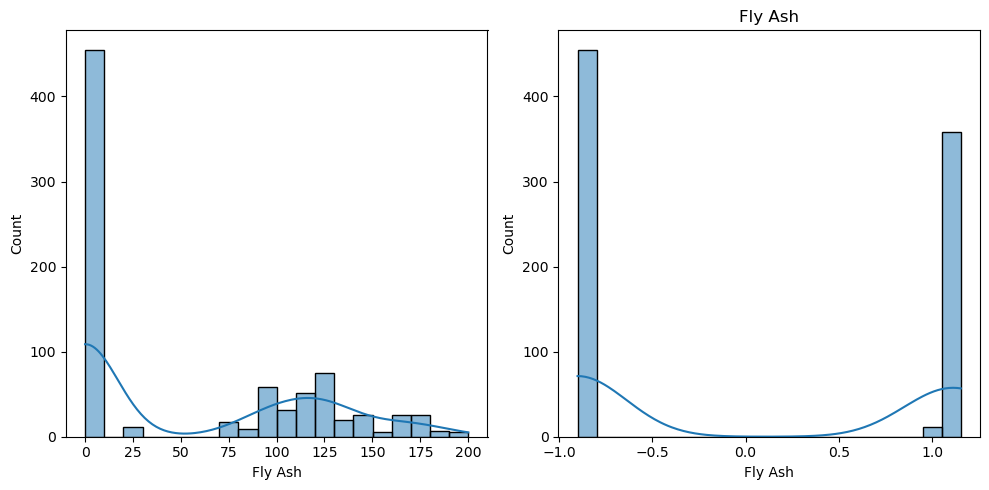

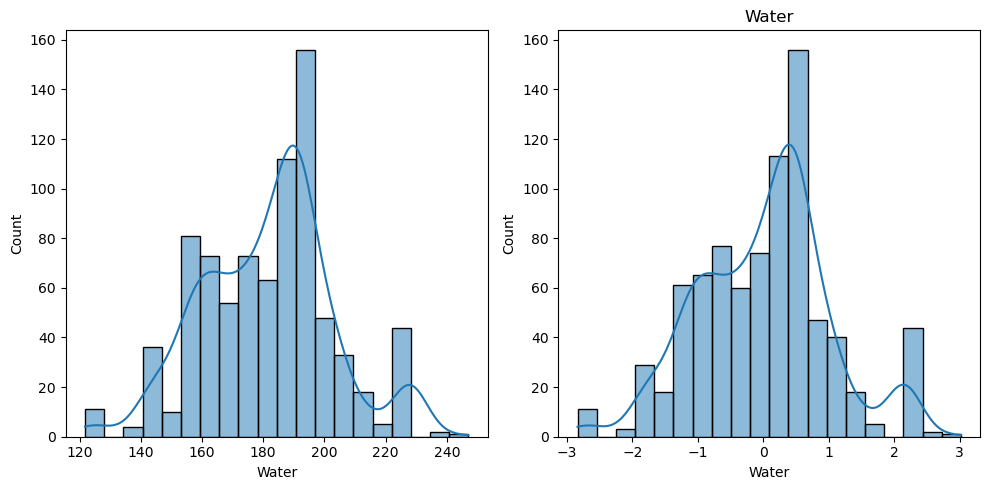

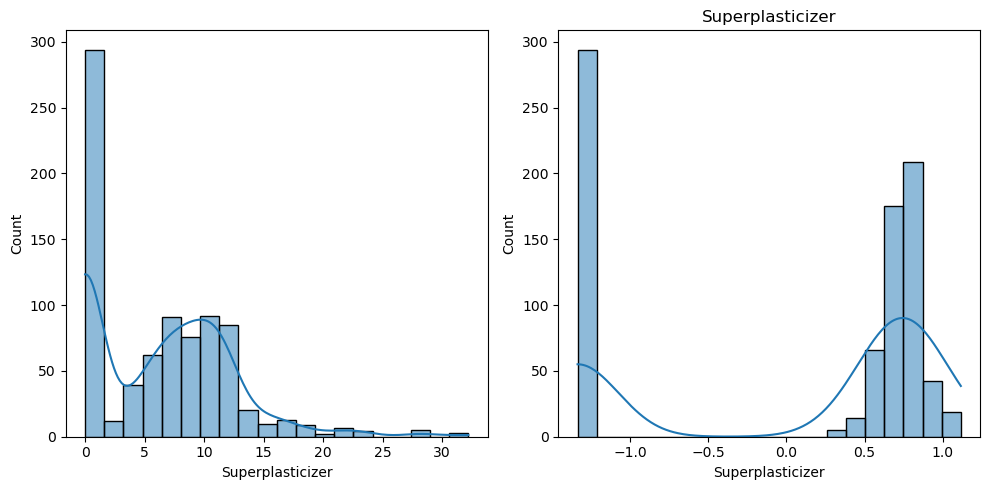

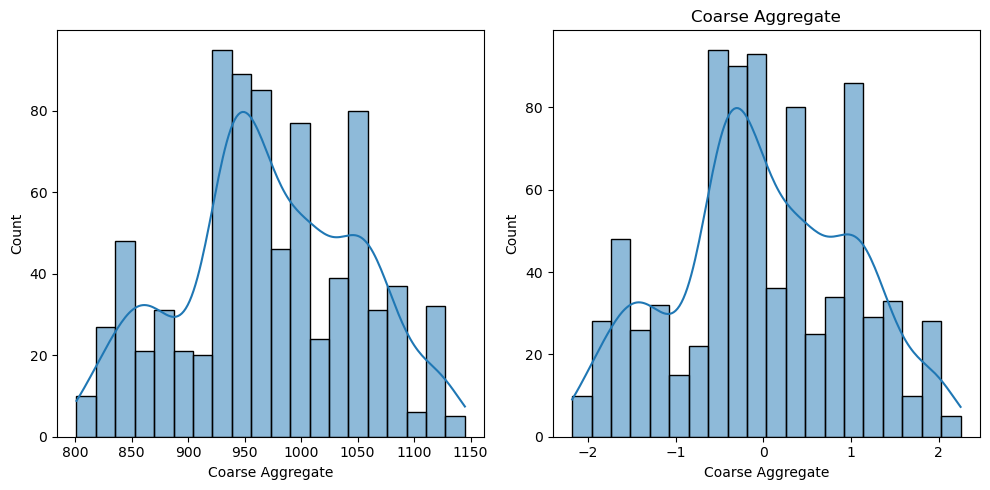

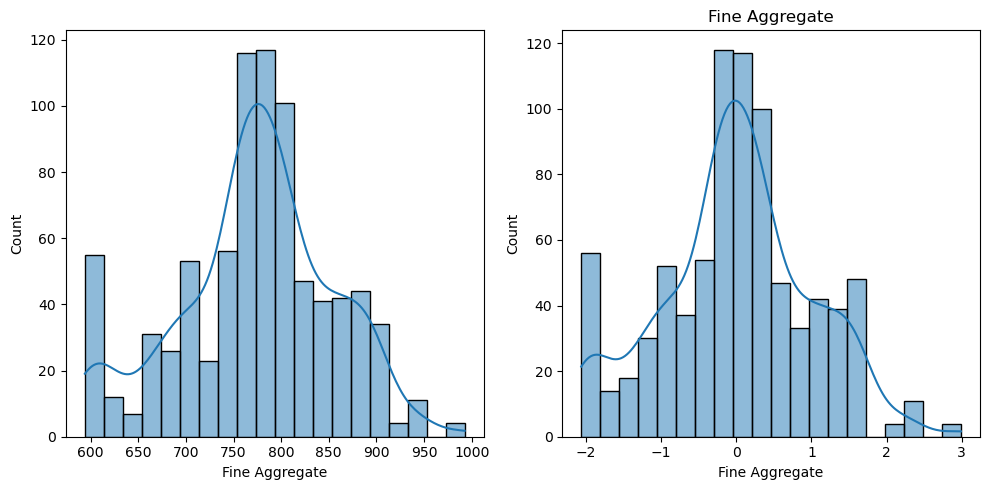

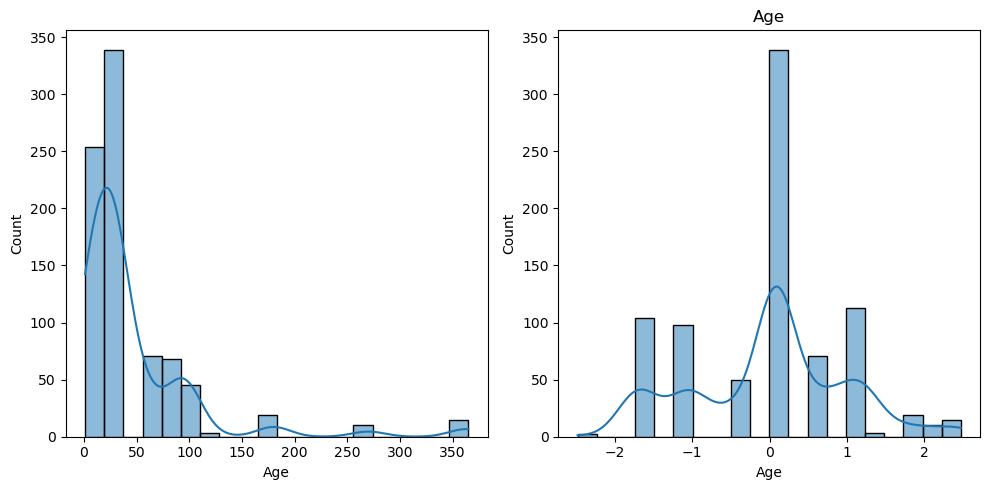

In [52]:
X_train_transformed=pd.DataFrame(X_train_transformed,columns=X_train.columns)

for col in X_train_transformed.columns:
    fig,ax=plt.subplots(1,2,figsize=(10,5))
    sns.histplot(X_train[col],ax=ax[0],kde=True,bins=20)
    plt.title(col)

    sns.histplot(X_train_transformed[col],ax=ax[1],kde=True,bins=20)
    plt.title(col)
    plt.tight_layout()
    plt.show()

In [ ]:
pt=PowerTransformer()

In [ ]:
X_train_transformed=pt.fit_transform(X_train)
X_test_transformed=pt.transform(X_test)

In [55]:
lr=LinearRegression()
lr.fit(X_train_transformed,y_train)
y_predict=lr.predict(X_test_transformed)

print("Accuracy of Linear Regression:",r2_score(y_test,y_predict))

Accuracy of Linear Regression: 0.8253744918217878


In [56]:
pt=PowerTransformer()
transformed_X=pt.fit_transform(X)
lr=LinearRegression()
print("LinearRegression Crossvalidation:",np.mean(cross_val_score(lr,transformed_X,y,scoring='r2')))

LinearRegression Crossvalidation: 0.6834625126992434


In [ ]:
pd.DataFrame()